# Vietnamese Sentiment Analysis: FastText and PhoBERT

Notebook nay duoc viet lai de chay on dinh theo thu tu cell.

- Phan 1: EDA va tien xu ly
- Phan 2: FastText baseline
- Phan 3: PhoBERT fine-tuning

Mac dinh `FAST_RUN = True` de co the chay tren CPU. Khi can train lon hon, doi `FAST_RUN = False` o cell config.

Sau khi chay cell cai dat thu vien, can restart kernel roi moi chay tiep.

In [20]:
!pip install -U "numpy<2" "transformers==4.39.3" "accelerate==0.29.2" "datasets==2.18.0" underthesea fasttext-wheel seaborn safetensors -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import json
import os
import random
import re
from collections import Counter
from pathlib import Path

import fasttext
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, Trainer, TrainingArguments, pipeline
from underthesea import word_tokenize

In [22]:
def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "resources").exists() and (candidate / "data").exists():
            return candidate.resolve()
    raise FileNotFoundError("Khong tim thay root cua project.")


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

RAW_TRAIN_PATH = PROJECT_ROOT / "data" / "preprocessed" / "train.csv"
RAW_TEST_PATH = PROJECT_ROOT / "data" / "preprocessed" / "test.csv"
RESOURCES_DIR = PROJECT_ROOT / "resources"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
PHOBERT_OUTPUT_DIR = OUTPUTS_DIR / "phobert-sentiment"
FASTTEXT_OUTPUT_DIR = OUTPUTS_DIR / "fasttext"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PHOBERT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FASTTEXT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

Project root: C:\Users\leanh\OneDrive\Documents\New project 2
CUDA available: True
Device: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [23]:
SEED = 42
MODEL_NAME = "vinai/phobert-base"
LABEL_ID_TO_NAME = {0: "negative", 1: "positive", 2: "neutral"}
LABEL_NAME_TO_ID = {value: key for key, value in LABEL_ID_TO_NAME.items()}
LABEL_DISPLAY = {0: "Negative", 1: "Positive", 2: "Neutral"}

FAST_RUN = False

PHOBERT_MAX_LENGTH = 64
PHOBERT_BATCH_SIZE = 8
PHOBERT_EPOCHS = 1 if FAST_RUN else 2
PHOBERT_LEARNING_RATE = 2e-5

FASTTEXT_LR = 0.5
FASTTEXT_EPOCHS = 10 if FAST_RUN else 25
FASTTEXT_WORD_NGRAMS = 2
FASTTEXT_DIM = 100

PHOBERT_SAMPLE_SIZES = {
    "train": 900,
    "val": 180,
    "test": 180,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# EDA and Preprocessing

In [24]:
with open(RESOURCES_DIR / "teencode.json", "r", encoding="utf-8") as f:
    TEENCODE_DICT = json.load(f)

with open(RESOURCES_DIR / "stopword.json", "r", encoding="utf-8") as f:
    stopword_data = json.load(f)

STOPWORDS = set(stopword_data["remove_always"]) - set(stopword_data["keep_for_sentiment"])


def clean_and_tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [TEENCODE_DICT.get(word, word) for word in text.split()]
    segmented = word_tokenize(" ".join(words), format="text")
    return [word for word in segmented.split() if word not in STOPWORDS]


def clean_text(text):
    return " ".join(clean_and_tokenize(text))


def save_fasttext_format(dataframe, output_path):
    lines = "__label__" + dataframe["flag"].astype(str) + " " + dataframe["comments_clean"].astype(str)
    lines.to_csv(output_path, index=False, header=False, encoding="utf-8")

In [ ]:
df = pd.read_csv(RAW_TRAIN_PATH)
df_test_external = pd.read_csv(RAW_TEST_PATH)

df = df.dropna(subset=["comments", "flag"])
df_test_external = df_test_external.dropna(subset=["comments", "flag"])

df["tokens"] = df["comments"].apply(clean_and_tokenize)
df["comments_clean"] = df["tokens"].apply(lambda tokens: " ".join(tokens))
df["length"] = df["tokens"].apply(len)

df_test_external["comments_clean"] = df_test_external["comments"].apply(clean_text)
df = df[df["comments_clean"].str.strip() != ""].copy()
df_test_external = df_test_external[df_test_external["comments_clean"].str.strip() != ""].copy()

print(df.head())
print("Train shape:", df.shape)
print("External test shape:", df_test_external.shape)
print(df["flag"].value_counts().sort_index())

                                            comments  flag  \
0  Bia ở đây nhiều vị cho mình chọn có rất nhiều ...     2   
1  Đồ ăn quá chán đc dăm ba miếng thịt đậu khô kh...     0   
2                                       áo mặc thích     1   
3  Bò bía chú này không ngon đâu ít đồ ăn lắm toà...     0   
4                         mấy bố ơi cái đó hook thôi     1   

                                              tokens  \
0  [bia, ở, vị, chọn, có, rất, bia, thủ_công, để,...   
1  [đồ_ăn, quá, chán, đc, dăm_ba, miếng, thịt, đậ...   
2                                   [áo, mặc, thích]   
3  [bò, bía, chú, không, ngon, đâu, đồ_ăn, lắm, t...   
4                                [mấy, bố, ơi, hook]   

                                      comments_clean  length  
0  bia ở vị chọn có rất bia thủ_công để lại ấn_tư...      55  
1  đồ_ăn quá chán đc dăm_ba miếng thịt đậu khô kh...      22  
2                                       áo mặc thích       3  
3  bò bía chú không ngon đâu đồ_ăn lắm

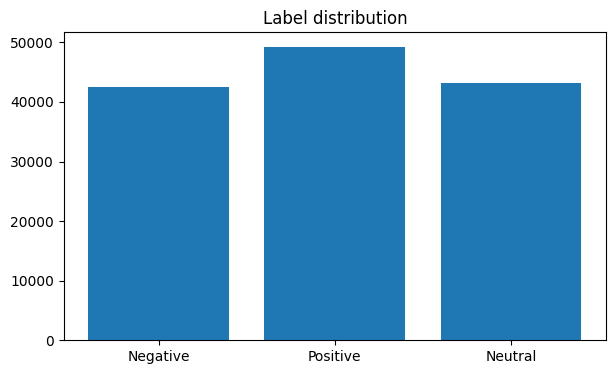

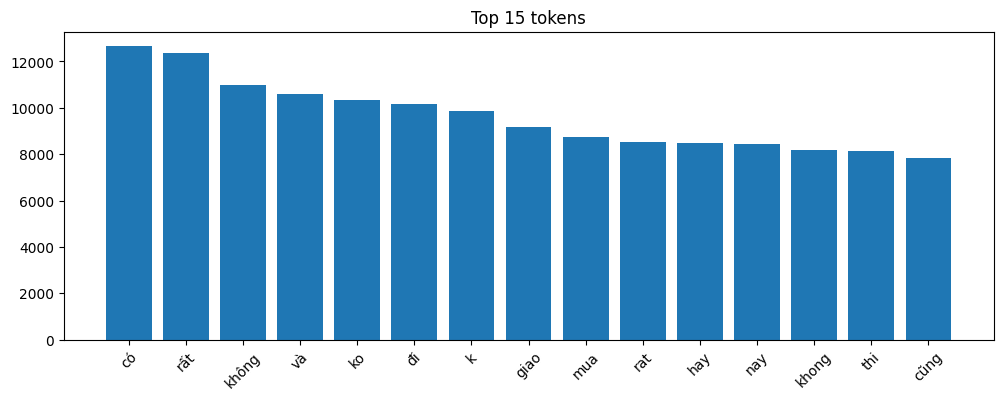

In [26]:
all_words = [word for tokens in df["tokens"] for word in tokens]
label_counts = df["flag"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar([LABEL_DISPLAY[i] for i in label_counts.index], label_counts.values)
plt.title("Label distribution")
plt.show()

top_15 = Counter(all_words).most_common(15)
words, freqs = zip(*top_15)
plt.figure(figsize=(12, 4))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.title("Top 15 tokens")
plt.show()

# FastText

In [27]:
X = df["comments_clean"]
y = df["flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=SEED, stratify=y_train
)

train_fasttext_df = pd.DataFrame({"comments_clean": X_train, "flag": y_train})
val_fasttext_df = pd.DataFrame({"comments_clean": X_val, "flag": y_val})
test_fasttext_df = pd.DataFrame({"comments_clean": X_test, "flag": y_test})

train_fasttext_path = PROCESSED_DIR / "train_fasttext.txt"
val_fasttext_path = PROCESSED_DIR / "val_fasttext.txt"
test_fasttext_path = PROCESSED_DIR / "test_fasttext.txt"

save_fasttext_format(train_fasttext_df, train_fasttext_path)
save_fasttext_format(val_fasttext_df, val_fasttext_path)
save_fasttext_format(test_fasttext_df, test_fasttext_path)

train_fasttext_df.to_csv(PROCESSED_DIR / "train_new_cleaned.csv", index=False, encoding="utf-8-sig")
val_fasttext_df.to_csv(PROCESSED_DIR / "val_cleaned.csv", index=False, encoding="utf-8-sig")
test_fasttext_df.to_csv(PROCESSED_DIR / "test_cleaned.csv", index=False, encoding="utf-8-sig")

print(train_fasttext_df.shape, val_fasttext_df.shape, test_fasttext_df.shape)

(97173, 2) (10798, 2) (26993, 2)


In [28]:
fasttext_model = fasttext.train_supervised(
    input=str(train_fasttext_path),
    lr=FASTTEXT_LR,
    epoch=FASTTEXT_EPOCHS,
    wordNgrams=FASTTEXT_WORD_NGRAMS,
    dim=FASTTEXT_DIM,
    loss="softmax"
)


def fasttext_predict_compat(model, text, k=1, threshold=0.0):
    text = str(text).strip()
    if not text:
        return ["__label__1"], np.asarray([0.0])
    predictions = model.f.predict(text, k, threshold, "strict")
    probs = [item[0] for item in predictions]
    labels = [item[1] for item in predictions]
    if not labels:
        return ["__label__1"], np.asarray([0.0])
    return labels, np.asarray(probs)


def parse_fasttext_label(label):
    return int(label.replace("__label__", ""))


y_true_fasttext = y_test.reset_index(drop=True).tolist()
y_pred_fasttext = []
for text in X_test.reset_index(drop=True).tolist():
    labels, probs = fasttext_predict_compat(fasttext_model, text)
    y_pred_fasttext.append(parse_fasttext_label(labels[0]))

print(classification_report(y_true_fasttext, y_pred_fasttext, target_names=["Negative", "Positive", "Neutral"]))

fasttext_model.save_model(str(FASTTEXT_OUTPUT_DIR / "fasttext_sentiment.bin"))

              precision    recall  f1-score   support

    Negative       0.76      0.82      0.78      8497
    Positive       0.76      0.63      0.69      9845
     Neutral       0.76      0.84      0.79      8651

    accuracy                           0.76     26993
   macro avg       0.76      0.76      0.76     26993
weighted avg       0.76      0.76      0.75     26993



FastText Accuracy: 0.7553
FastText Precision: 0.7553
FastText Recall: 0.7553
FastText F1-score: 0.7523


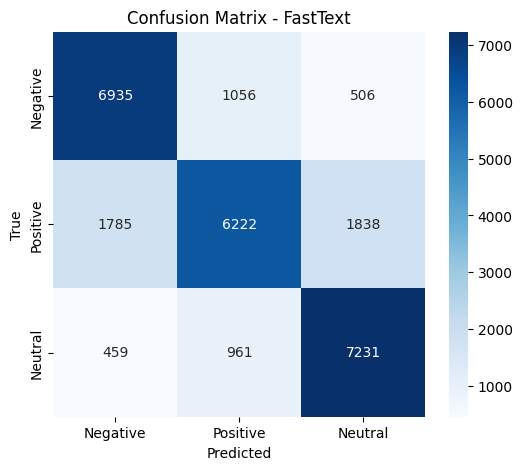

In [29]:
accuracy = accuracy_score(y_true_fasttext, y_pred_fasttext)
precision, recall, f1, _ = precision_recall_fscore_support(y_true_fasttext, y_pred_fasttext, average="weighted")
cm = confusion_matrix(y_true_fasttext, y_pred_fasttext)

print(f"FastText Accuracy: {accuracy:.4f}")
print(f"FastText Precision: {precision:.4f}")
print(f"FastText Recall: {recall:.4f}")
print(f"FastText F1-score: {f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[LABEL_DISPLAY[i] for i in range(3)], yticklabels=[LABEL_DISPLAY[i] for i in range(3)])
plt.title("Confusion Matrix - FastText")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# PhoBERT

In [30]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["flag"])
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=SEED, stratify=train_df["flag"])

def sample_per_label(dataframe, total_size):
    per_label = max(1, total_size // len(LABEL_ID_TO_NAME))
    parts = []
    for label_id in sorted(LABEL_ID_TO_NAME.keys()):
        part = dataframe[dataframe["flag"] == label_id]
        parts.append(part.sample(n=min(len(part), per_label), random_state=SEED))
    return pd.concat(parts, axis=0).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

if FAST_RUN:
    train_df = sample_per_label(train_df, PHOBERT_SAMPLE_SIZES["train"])
    val_df = sample_per_label(val_df, PHOBERT_SAMPLE_SIZES["val"])
    test_df = sample_per_label(test_df, PHOBERT_SAMPLE_SIZES["test"])

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["flag"].value_counts().sort_index())

(97173, 5) (10798, 5) (26993, 5)
flag
0    30591
1    35441
2    31141
Name: count, dtype: int64


In [31]:
train_dataset = Dataset.from_pandas(train_df[["comments_clean", "flag"]].rename(columns={"flag": "labels"}), preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["comments_clean", "flag"]].rename(columns={"flag": "labels"}), preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["comments_clean", "flag"]].rename(columns={"flag": "labels"}), preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)
model.config.id2label = LABEL_ID_TO_NAME
model.config.label2id = LABEL_NAME_TO_ID

def preprocess_function(examples):
    texts = [str(x).strip() for x in examples["comments_clean"]]
    return tokenizer(texts, truncation=True, max_length=PHOBERT_MAX_LENGTH)

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(tokenized_train[0])

c:\Users\leanh\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 26993/26993 [00:04<00:00, 5781.47 examples/s]

{'comments_clean': 'me gia_đo ko noi', 'labels': 1, 'input_ids': [0, 4407, 49187, 1595, 5516, 13568, 2], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [32]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="weighted")
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir=str(PHOBERT_OUTPUT_DIR),
    learning_rate=PHOBERT_LEARNING_RATE,
    per_device_train_batch_size=PHOBERT_BATCH_SIZE,
    per_device_eval_batch_size=PHOBERT_BATCH_SIZE,
    num_train_epochs=PHOBERT_EPOCHS,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=25,
    load_best_model_at_end=True,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

trainer.train()

c:\Users\leanh\AppData\Local\Programs\Python\Python312\Lib\site-packages\accelerate\accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
  0%|          | 26/24294 [00:05<1:17:50,  5.20it/s]

{'loss': 1.0972, 'grad_norm': 6.788715839385986, 'learning_rate': 1.9979418786531654e-05, 'epoch': 0.0}


  0%|          | 51/24294 [00:10<1:20:38,  5.01it/s]

{'loss': 1.0939, 'grad_norm': 8.70539379119873, 'learning_rate': 1.995883757306331e-05, 'epoch': 0.0}


  0%|          | 76/24294 [00:15<1:24:16,  4.79it/s]

...

{'eval_loss': 0.5435136556625366, 'eval_accuracy': 0.7930172254121134, 'eval_precision': 0.7929448660362804, 'eval_recall': 0.7930172254121134, 'eval_f1': 0.7928968785692413, 'eval_runtime': 52.4591, 'eval_samples_per_second': 205.837, 'eval_steps_per_second': 25.734, 'epoch': 2.0}


100%|██████████| 24294/24294 [1:46:04<00:00,  3.56it/s]

{'train_runtime': 6364.405, 'train_samples_per_second': 30.536, 'train_steps_per_second': 3.817, 'train_loss': 0.5819813593764497, 'epoch': 2.0}


100%|██████████| 24294/24294 [1:46:04<00:00,  3.82it/s]


TrainOutput(global_step=24294, training_loss=0.5819813593764497, metrics={'train_runtime': 6364.405, 'train_samples_per_second': 30.536, 'train_steps_per_second': 3.817, 'train_loss': 0.5819813593764497, 'epoch': 2.0})

100%|██████████| 3375/3375 [02:16<00:00, 24.73it/s]


              precision    recall  f1-score   support

    Negative       0.80      0.77      0.79      8497
    Positive       0.72      0.72      0.72      9845
     Neutral       0.81      0.82      0.82      8651

    accuracy                           0.77     26993
   macro avg       0.77      0.77      0.77     26993
weighted avg       0.77      0.77      0.77     26993



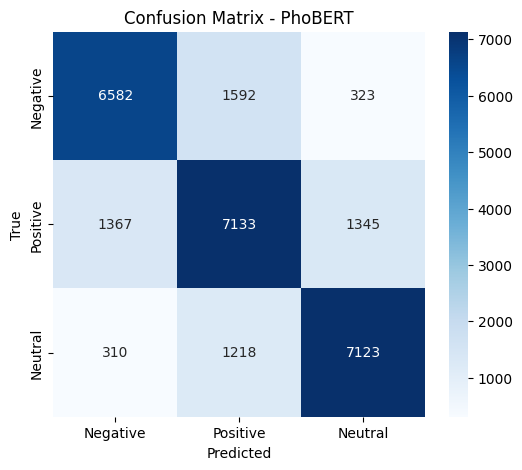

('C:\\Users\\leanh\\OneDrive\\Documents\\New project 2\\outputs\\phobert-sentiment\\tokenizer_config.json',
 'C:\\Users\\leanh\\OneDrive\\Documents\\New project 2\\outputs\\phobert-sentiment\\special_tokens_map.json',
 'C:\\Users\\leanh\\OneDrive\\Documents\\New project 2\\outputs\\phobert-sentiment\\vocab.txt',
 'C:\\Users\\leanh\\OneDrive\\Documents\\New project 2\\outputs\\phobert-sentiment\\bpe.codes',
 'C:\\Users\\leanh\\OneDrive\\Documents\\New project 2\\outputs\\phobert-sentiment\\added_tokens.json')

In [33]:
predictions_output = trainer.predict(tokenized_test)
y_pred_phobert = np.argmax(predictions_output.predictions, axis=1)
y_true_phobert = np.array(tokenized_test["labels"])

print(classification_report(y_true_phobert, y_pred_phobert, target_names=["Negative", "Positive", "Neutral"]))

cm = confusion_matrix(y_true_phobert, y_pred_phobert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[LABEL_DISPLAY[i] for i in range(3)], yticklabels=[LABEL_DISPLAY[i] for i in range(3)])
plt.title("Confusion Matrix - PhoBERT")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

trainer.save_model(str(PHOBERT_OUTPUT_DIR))
tokenizer.save_pretrained(str(PHOBERT_OUTPUT_DIR))

In [ ]:
clf = pipeline("text-classification", model=str(PHOBERT_OUTPUT_DIR), tokenizer=str(PHOBERT_OUTPUT_DIR), truncation=True)

def predict_fasttext(text):
    cleaned = clean_text(text)
    labels, probs = fasttext_predict_compat(fasttext_model, cleaned)
    return {
        "cleaned": cleaned,
        "label": LABEL_DISPLAY[parse_fasttext_label(labels[0])],
        "score": float(probs[0]),
    }


def predict_phobert(text):
    cleaned = clean_text(text)
    result = clf(cleaned)[0]
    return {
        "cleaned": cleaned,
        "label": result["label"],
        "score": result["score"],
    }


sample_text = "quan an nay kha on, phuc vu nhanh va lich su"
print("FastText:", predict_fasttext(sample_text))
print("PhoBERT:", predict_phobert(sample_text))

FastText: {'cleaned': 'quan an nay kha_on phuc vu nhanh va lich_su', 'label': 'Neutral', 'score': 0.9866840839385986}
PhoBERT: {'cleaned': 'quan an nay kha_on phuc vu nhanh va lich_su', 'label': 'neutral', 'score': 0.49520742893218994}
